## Import Library

In [2]:
!pip install scikit-learn==1.7.2

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

## Load & sort dataset

In [4]:
from google.colab import drive
drive.mount("/content/drive")

df = pd.read_csv(
    "/content/drive/MyDrive/Capstone_CC26-PSU349/dataset/"
    "nasa_power_dav/dataset_features.csv"
)

# Time-based sort — WAJIB sebelum split
df = df.sort_values(["YEAR", "MO", "DY", "HR"]).reset_index(drop=True)
df = df.dropna()

print("Shape:", df.shape)
print(df[["YEAR","MO","DY","HR","ALLSKY_SFC_UV_INDEX","T2M","RH2M","WS2M"]].describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (78912, 18)
               YEAR            MO            DY            HR  \
count  78912.000000  78912.000000  78912.000000  78912.000000   
mean    2022.499544      6.521898     15.732664     11.500000   
std        1.708192      3.449008      8.801426      3.452074   
min     2020.000000      1.000000      1.000000      6.000000   
25%     2021.000000      4.000000      8.000000      8.750000   
50%     2022.500000      7.000000     16.000000     11.500000   
75%     2024.000000     10.000000     23.000000     14.250000   
max     2025.000000     12.000000     31.000000     17.000000   

       ALLSKY_SFC_UV_INDEX           T2M          RH2M          WS2M  
count         78912.000000  78912.000000  78912.000000  78912.000000  
mean              4.622155     27.637792     76.490412      1.908638  
std               3.888152      1.815150      9.81012

## Target creation

Compute comfort score 0.0–1.0

In [5]:
def compute_comfort_score(uvi, t2m, rh2m, ws2m):
    """
    Comfort score untuk berjemur — komponen:
    UV (55%) + Suhu (20%) + Kelembapan (15%) + Angin (10%)
    """
    uv_score  = 1.0 / (1.0 + np.exp(0.8 * (uvi - 5)))
    t_score   = np.exp(-0.5 * ((t2m - 28.0) / 5.0) ** 2)
    rh_score  = np.exp(-0.5 * ((rh2m - 62.0) / 20.0) ** 2)
    ws_score  = np.exp(-0.5 * ((ws2m - 3.0) / 3.0) ** 2)
    comfort   = 0.55*uv_score + 0.20*t_score + 0.15*rh_score + 0.10*ws_score
    return float(np.clip(comfort, 0.0, 1.0))

df["COMFORT_SCORE"] = df.apply(
    lambda r: compute_comfort_score(
        r["ALLSKY_SFC_UV_INDEX"], r["T2M"], r["RH2M"], r["WS2M"]
    ), axis=1
)

print("\nDistribusi COMFORT_SCORE:")
print(df["COMFORT_SCORE"].describe())
print(f"\nScore > 0.7 (sangat nyaman): {(df['COMFORT_SCORE'] > 0.7).mean()*100:.1f}%")
print(f"Score 0.4–0.7 (cukup)      : {((df['COMFORT_SCORE'] >= 0.4) & (df['COMFORT_SCORE'] <= 0.7)).mean()*100:.1f}%")
print(f"Score < 0.4 (kurang nyaman): {(df['COMFORT_SCORE'] < 0.4).mean()*100:.1f}%")


Distribusi COMFORT_SCORE:
count    78912.000000
mean         0.688050
std          0.205952
min          0.245144
25%          0.458275
50%          0.766930
75%          0.880355
max          0.988846
Name: COMFORT_SCORE, dtype: float64

Score > 0.7 (sangat nyaman): 53.8%
Score 0.4–0.7 (cukup)      : 41.8%
Score < 0.4 (kurang nyaman): 4.4%


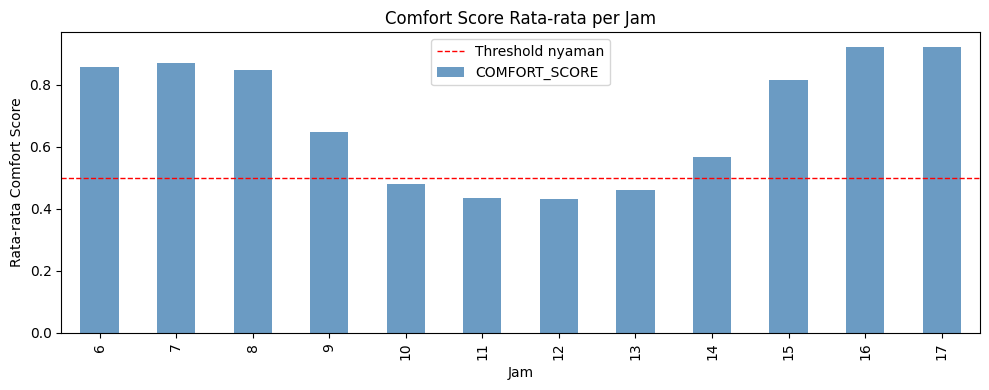

In [6]:
plt.figure(figsize=(10, 4))
df.groupby("HR")["COMFORT_SCORE"].mean().plot(
    kind="bar", color="steelblue", alpha=0.8
)
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Threshold nyaman")
plt.xlabel("Jam"); plt.ylabel("Rata-rata Comfort Score")
plt.title("Comfort Score Rata-rata per Jam")
plt.legend(); plt.tight_layout()
plt.savefig("comfort_by_hour.png", dpi=150)
plt.show()

## feature engineering

Cyclic encoding untuk waktu

In [7]:
df["HR_sin"]    = np.sin(2 * np.pi * df["HR"] / 24)
df["HR_cos"]    = np.cos(2 * np.pi * df["HR"] / 24)
df["BULAN_sin"] = np.sin(2 * np.pi * df["MO"] / 12)
df["BULAN_cos"] = np.cos(2 * np.pi * df["MO"] / 12)

Interaksi fitur

In [8]:
df["UV_x_T2M"]  = df["ALLSKY_SFC_UV_INDEX"] * df["T2M"]
df["UV_x_RH"]   = df["ALLSKY_SFC_UV_INDEX"] * df["RH2M"]
df["T2M_x_RH"]  = df["T2M"] * df["RH2M"]

Encoding lokasi — one-hot (hanya 3 nilai, tidak perlu embedding)

In [9]:
if "LOKASI" in df.columns:
    df = pd.get_dummies(df, columns=["LOKASI"], prefix="lok", drop_first=False)
    lokasi_cols = [c for c in df.columns if c.startswith("lok_")]
    print(f"Lokasi one-hot: {lokasi_cols}")
else:
    lokasi_cols = []

Lokasi one-hot: ['lok_Bali', 'lok_Lombok', 'lok_Raja Ampat']


Encoding musim — sudah ada di dataset, one-hot

In [10]:
if "MUSIM" in df.columns:
    df = pd.get_dummies(df, columns=["MUSIM"], prefix="musim", drop_first=False)
    musim_cols = [c for c in df.columns if c.startswith("musim_")]
else:
    musim_cols = []

Definisi FEATURES

UVI tidak dimasukkan langsung karena comfort_score sudah memasukkan UVI dalam formula — akan ada leakage jika dimasukkan

In [11]:
FEATURES = [
    # Cuaca dasar
    "T2M", "RH2M", "WS2M",
    # Waktu siklikal
    "HR_sin", "HR_cos",
    "BULAN_sin", "BULAN_cos",
    # Interaksi non-UV (tidak mengandung sinyal UV langsung)
    "T2M_x_RH",
    # Lokasi & musim
    *lokasi_cols,
    *musim_cols,
]

TARGET = "COMFORT_SCORE"

print(f"Jumlah fitur: {len(FEATURES)}")
print("Fitur:", FEATURES)

print("\nKorelasi fitur vs COMFORT_SCORE:")
corr = df[FEATURES + [TARGET]].corr()[TARGET].sort_values()
print(corr.round(3))

Jumlah fitur: 14
Fitur: ['T2M', 'RH2M', 'WS2M', 'HR_sin', 'HR_cos', 'BULAN_sin', 'BULAN_cos', 'T2M_x_RH', 'lok_Bali', 'lok_Lombok', 'lok_Raja Ampat', 'musim_Hujan', 'musim_Kemarau', 'musim_Peralihan']

Korelasi fitur vs COMFORT_SCORE:
T2M               -0.380
HR_sin            -0.066
BULAN_cos         -0.057
lok_Bali          -0.049
musim_Peralihan   -0.046
musim_Hujan       -0.026
BULAN_sin         -0.016
lok_Lombok         0.002
WS2M               0.029
lok_Raja Ampat     0.047
musim_Kemarau      0.072
T2M_x_RH           0.267
RH2M               0.384
HR_cos             0.820
COMFORT_SCORE      1.000
Name: COMFORT_SCORE, dtype: float64


## Time-based split 80/10/10

In [12]:
n = len(df)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 63,129 | Val: 7,891 | Test: 7,892


In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

## training evaluasi

In [14]:
def evaluate(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    p_tr = model.predict(X_tr)
    p_v  = model.predict(X_v)

    print(f"\n=== {name} ===")
    print(f"Train → MAE: {mean_absolute_error(y_tr, p_tr):.5f} | R²: {r2_score(y_tr, p_tr):.4f}")
    print(f"Val   → MAE: {mean_absolute_error(y_v, p_v):.5f} | R²: {r2_score(y_v, p_v):.4f}")

    gap = mean_absolute_error(y_v, p_v) - mean_absolute_error(y_tr, p_tr)
    if gap > 0.02:
        print(f"⚠️  Gap val-train {gap:.4f} — kemungkinan overfit")
    else:
        print(f"✅ Gap kecil ({gap:.4f}) — generalisasi baik")

    return mean_absolute_error(y_v, p_v), model

### random forest

In [15]:
rf_mae, rf_model = evaluate(
    RandomForestRegressor(
        n_estimators=200, max_depth=10,
        min_samples_leaf=5, random_state=42, n_jobs=-1
    ),
    X_train_sc, y_train, X_val_sc, y_val, "Random Forest"
)


=== Random Forest ===
Train → MAE: 0.02316 | R²: 0.9530
Val   → MAE: 0.03184 | R²: 0.9083
✅ Gap kecil (0.0087) — generalisasi baik


### xgboost

In [16]:
xgb_mae, xgb_model = evaluate(
    XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, random_state=42
    ),
    X_train_sc, y_train, X_val_sc, y_val, "XGBoost"
)


=== XGBoost ===
Train → MAE: 0.02414 | R²: 0.9486
Val   → MAE: 0.03169 | R²: 0.9079
✅ Gap kecil (0.0075) — generalisasi baik


### best model

In [17]:
best_name  = "Random Forest" if rf_mae <= xgb_mae else "XGBoost"
best_model = rf_model if rf_mae <= xgb_mae else xgb_model

print(f"\n{'='*45}")
print(f"Model terpilih: {best_name}")


Model terpilih: XGBoost


### evaluasi

In [18]:
y_pred_test = best_model.predict(X_test_sc)
test_mae    = mean_absolute_error(y_test, y_pred_test)
test_r2     = r2_score(y_test, y_pred_test)
print(f"Test MAE: {test_mae:.5f}")
print(f"Test R² : {test_r2:.4f}")

Test MAE: 0.02951
Test R² : 0.9244


In [19]:
print(f"\nInterpretasi: error prediksi rata-rata = ±{test_mae:.3f} dari skala 0–1")
print(f"  Pada durasi 30 menit: error = ±{30 * test_mae:.1f} menit")


Interpretasi: error prediksi rata-rata = ±0.030 dari skala 0–1
  Pada durasi 30 menit: error = ±0.9 menit


## feature importance


Top 10 Feature Importance:
HR_cos            0.7052
HR_sin            0.1816
musim_Kemarau     0.0492
lok_Raja Ampat    0.0105
BULAN_cos         0.0089
RH2M              0.0077
T2M               0.0065
lok_Bali          0.0059
BULAN_sin         0.0058
lok_Lombok        0.0053
dtype: float32


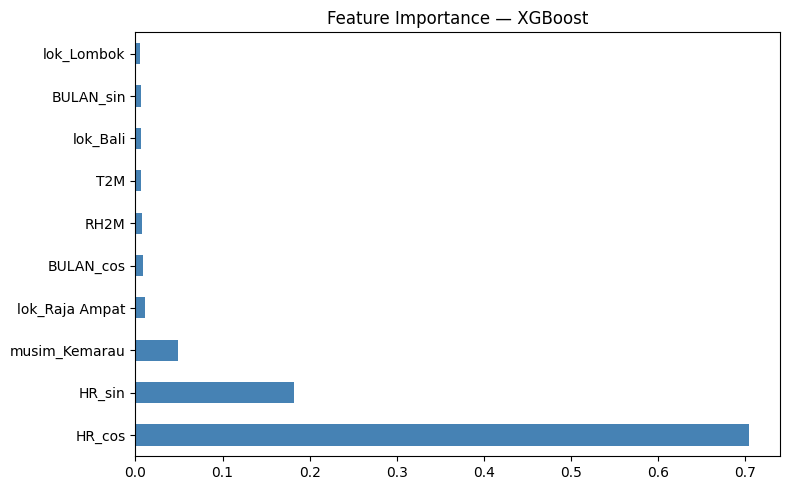

In [20]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

print("\nTop 10 Feature Importance:")
print(feat_imp.head(10).round(4))

feat_imp.head(10).plot(
    kind="barh", figsize=(8, 5),
    title=f"Feature Importance — {best_name}",
    color="steelblue"
)
plt.tight_layout()
plt.savefig("feature_importance_besttime.png", dpi=150)
plt.show()

In [21]:
# Imports required for ColumnTransformer, OneHotEncoder, and Pipeline components
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

num_cols = [col for col in FEATURES if not (col.startswith("lok_") or col.startswith("musim_"))]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),

], remainder='passthrough')

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor())
])

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# 1. Prepare raw data for Pipeline training (using original categorical columns)
# We use df_train and df_val but we need the original 'LOKASI' and 'MUSIM' strings,
# which were dropped/transformed in previous cells.
# Let's re-identify the raw inputs from the sorted dataframe.
raw_features = ['T2M', 'RH2M', 'WS2M', 'HR_sin', 'HR_cos', 'BULAN_sin', 'BULAN_cos', 'T2M_x_RH', 'LOKASI', 'MUSIM']

# Note: We re-fetch from the original 'df' before it was one-hot encoded manually
df_raw = pd.read_csv("/content/drive/MyDrive/Capstone_CC26-PSU349/dataset/nasa_power_dav/dataset_features.csv")
df_raw = df_raw.sort_values(["YEAR", "MO", "DY", "HR"]).reset_index(drop=True).dropna()

# Re-apply cyclic and interaction features to the raw dataframe
df_raw["HR_sin"] = np.sin(2 * np.pi * df_raw["HR"] / 24)
df_raw["HR_cos"] = np.cos(2 * np.pi * df_raw["HR"] / 24)
df_raw["BULAN_sin"] = np.sin(2 * np.pi * df_raw["MO"] / 12)
df_raw["BULAN_cos"] = np.cos(2 * np.pi * df_raw["MO"] / 12)
df_raw["T2M_x_RH"] = df_raw["T2M"] * df_raw["RH2M"]
df_raw["COMFORT_SCORE"] = df_raw.apply(lambda r: compute_comfort_score(r["ALLSKY_SFC_UV_INDEX"], r["T2M"], r["RH2M"], r["WS2M"]), axis=1)

# Split again
n_raw = len(df_raw)
tr_end = int(n_raw * 0.8)
X_train_raw = df_raw.iloc[:tr_end][raw_features]
y_train_raw = df_raw.iloc[:tr_end]["COMFORT_SCORE"]

# 2. Define Preprocessor
numeric_features = ['T2M', 'RH2M', 'WS2M', 'HR_sin', 'HR_cos', 'BULAN_sin', 'BULAN_cos', 'T2M_x_RH']
categorical_features = ['LOKASI', 'MUSIM']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 3. Create and Fit Final Pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, random_state=42
    ))
])

final_pipeline.fit(X_train_raw, y_train_raw)

# 4. Export the robust pipeline
joblib.dump(final_pipeline, "best_time_pipeline.pkl")
print("Robust Pipeline saved to 'best_time_pipeline.pkl'")
print("This pipeline accepts raw 'LOKASI' and 'MUSIM' as strings.")

Robust Pipeline saved to 'best_time_pipeline.pkl'
This pipeline accepts raw 'LOKASI' and 'MUSIM' as strings.


In [23]:
# Verification for Inference.py
test_inference_data = pd.DataFrame([{
    "T2M": 28, "RH2M": 75, "WS2M": 2.0,
    "HR_sin": np.sin(2*np.pi*9/24),
    "HR_cos": np.cos(2*np.pi*9/24),
    "BULAN_sin": np.sin(2*np.pi*6/12),
    "BULAN_cos": np.cos(2*np.pi*6/12),
    "T2M_x_RH": 28*75,
    "LOKASI": "Bali",
    "MUSIM": "Kemarau"
}])

prediction = final_pipeline.predict(test_inference_data)
print(f"Prediction using raw strings: {prediction[0]:.4f}")

Prediction using raw strings: 0.7479


In [24]:
joblib.dump({
    "model":      best_model,
    "model_name": best_name,
    "scaler":     scaler,
    "features":   FEATURES,
    "target":     TARGET,
    "test_mae":   test_mae,
    "test_r2":    test_r2,
}, "model_best_time.joblib")

print(f"Model '{best_name}' disimpan ke model_best_time.joblib")

Model 'XGBoost' disimpan ke model_best_time.joblib


In [25]:
'''from sklearn.pipeline import Pipeline

best_time_pipeline = Pipeline([
    ("scaler", scaler),
    ("model",  best_model)
])

joblib.dump(best_time_pipeline, "best_time_pipeline.pkl")
print("Pipeline saved: best_time_pipeline.pkl")

test_features = {
    "T2M": 28, "RH2M": 75, "WS2M": 2.0,
    "HR_sin": np.sin(2*np.pi*9/24),
    "HR_cos": np.cos(2*np.pi*9/24),
    "BULAN_sin": np.sin(2*np.pi*6/12),
    "BULAN_cos": np.cos(2*np.pi*6/12),
    "T2M_x_RH": 28*75,
}

for feature in FEATURES:
    if feature not in test_features:
        test_features[feature] = 0

test_input = pd.DataFrame([test_features])

print("Test predict:", best_time_pipeline.predict(test_input))'''

'from sklearn.pipeline import Pipeline\n\nbest_time_pipeline = Pipeline([\n    ("scaler", scaler),\n    ("model",  best_model)\n])\n\njoblib.dump(best_time_pipeline, "best_time_pipeline.pkl")\nprint("Pipeline saved: best_time_pipeline.pkl")\n\ntest_features = {\n    "T2M": 28, "RH2M": 75, "WS2M": 2.0,\n    "HR_sin": np.sin(2*np.pi*9/24),\n    "HR_cos": np.cos(2*np.pi*9/24),\n    "BULAN_sin": np.sin(2*np.pi*6/12),\n    "BULAN_cos": np.cos(2*np.pi*6/12),\n    "T2M_x_RH": 28*75,\n}\n\nfor feature in FEATURES:\n    if feature not in test_features:\n        test_features[feature] = 0\n\ntest_input = pd.DataFrame([test_features])\n\nprint("Test predict:", best_time_pipeline.predict(test_input))'

## Inference function

In [26]:
def get_hour_label(hr):
    return f"{hr:02d}:00"

def predict_best_time(
    bulan: int,
    t2m_per_jam: dict,
    rh2m_per_jam: dict,
    ws2m_per_jam: dict,
    uvi_per_jam: dict = None,      # ← tambahkan UVI untuk filter
    lokasi: str = None,
    musim: str = None,
    top_n: int = 3,
    window_start: int = 7,         # ← batas jam paling awal
    window_end: int = 16,          # ← batas jam paling akhir
    min_uvi_for_best: float = 1.0  # ← UV minimum agar jam bisa jadi "terbaik"
) -> dict:
    """
    window_start dan window_end membatasi jam yang masuk kandidat
    "waktu terbaik" — default 07:00–16:00 (waktu berjemur wajar).

    Jam di luar window tetap ditampilkan di hourly_forecast
    tapi tidak akan masuk best_hours.
    """
    hours = sorted(t2m_per_jam.keys())
    records = []

    for hr in hours:
        t2m  = t2m_per_jam[hr]
        rh2m = rh2m_per_jam.get(hr, 75.0)
        ws2m = ws2m_per_jam.get(hr, 2.0)

        hr_sin    = np.sin(2 * np.pi * hr / 24)
        hr_cos    = np.cos(2 * np.pi * hr / 24)
        bulan_sin = np.sin(2 * np.pi * bulan / 12)
        bulan_cos = np.cos(2 * np.pi * bulan / 12)
        t2m_x_rh  = t2m * rh2m

        feature_arr = []
        for feat in FEATURES:
            if feat == "T2M":         feature_arr.append(t2m)
            elif feat == "RH2M":      feature_arr.append(rh2m)
            elif feat == "WS2M":      feature_arr.append(ws2m)
            elif feat == "HR_sin":    feature_arr.append(hr_sin)
            elif feat == "HR_cos":    feature_arr.append(hr_cos)
            elif feat == "BULAN_sin": feature_arr.append(bulan_sin)
            elif feat == "BULAN_cos": feature_arr.append(bulan_cos)
            elif feat == "T2M_x_RH":  feature_arr.append(t2m_x_rh)
            elif feat.startswith("lok_"):
                feature_arr.append(
                    1.0 if lokasi and feat == f"lok_{lokasi}" else 0.0
                )
            elif feat.startswith("musim_"):
                feature_arr.append(
                    1.0 if musim and feat == f"musim_{musim}" else 0.0
                )
            else:
                feature_arr.append(0.0)

        records.append(feature_arr)

    X_input  = np.array(records)
    X_scaled = scaler.transform(X_input)
    scores   = best_model.predict(X_scaled)

    results_df = pd.DataFrame({
        "hr":    hours,
        "score": scores,
        "t2m":   [t2m_per_jam[h] for h in hours],
        "rh2m":  [rh2m_per_jam.get(h, 75.0) for h in hours],
        "ws2m":  [ws2m_per_jam.get(h, 2.0) for h in hours],
        "uvi":   [(uvi_per_jam or {}).get(h, None) for h in hours],
    })

    # ── Filter untuk kandidat "waktu terbaik" ───────────────
    # Hanya jam dalam window berjemur yang bisa jadi best_hours
    candidate_df = results_df[
        (results_df["hr"] >= window_start) &
        (results_df["hr"] <= window_end)
    ].copy()

    # Filter tambahan: kalau UVI tersedia, exclude jam UV terlalu rendah
    if uvi_per_jam is not None:
        candidate_df = candidate_df[
            candidate_df["uvi"] >= min_uvi_for_best
        ]

    # Fallback: kalau semua jam di-filter, gunakan semua jam di window
    if candidate_df.empty:
        candidate_df = results_df[
            (results_df["hr"] >= window_start) &
            (results_df["hr"] <= window_end)
        ]

    sorted_candidates = candidate_df.sort_values("score", ascending=False)
    best_hours  = sorted_candidates.head(top_n)["hr"].tolist()
    worst_hours = sorted_candidates.tail(top_n)["hr"].tolist()

    # Hourly forecast — semua jam tetap ditampilkan
    hourly_forecast = []
    for _, row in results_df.sort_values("hr").iterrows():
        s  = row["score"]
        hr = int(row["hr"])

        # Tandai jam di luar window
        out_of_window = hr < window_start or hr > window_end

        if out_of_window:
            label, emoji = "Di luar waktu berjemur", "⚪"
        elif s >= 0.65:
            label, emoji = "Sangat Nyaman", "🟢"
        elif s >= 0.50:
            label, emoji = "Cukup Nyaman",  "🟡"
        elif s >= 0.35:
            label, emoji = "Kurang Nyaman", "🟠"
        else:
            label, emoji = "Tidak Nyaman",  "🔴"

        hourly_forecast.append({
            "hour":           get_hour_label(hr),
            "score":          round(float(s), 3),
            "label":          label,
            "emoji":          emoji,
            "temperature":    round(float(row["t2m"]), 1),
            "humidity":       round(float(row["rh2m"]), 1),
            "in_window":      not out_of_window,
        })

    # Format display
    def hours_to_display(hrs):
        hrs = sorted(hrs)
        if len(hrs) > 1 and hrs[-1] - hrs[0] == len(hrs) - 1:
            return f"{get_hour_label(hrs[0])}–{get_hour_label(hrs[-1])}"
        return ", ".join([get_hour_label(h) for h in hrs])

    best_sorted  = sorted(best_hours)
    worst_sorted = sorted(worst_hours)

    insight_parts = [
        f"Waktu terbaik untuk berjemur: {hours_to_display(best_sorted)}",
        f"Hindari berjemur saat: {hours_to_display(worst_sorted)}",
        #f"Waktu rekomendasi: {get_hour_label(window_start)}–"
        #f"{get_hour_label(window_end)}",
    ]

    # Insight kondisi spesifik
    peak_temp_hr = max(
        {h: t for h, t in t2m_per_jam.items()
         if window_start <= h <= window_end},
        key=lambda h: t2m_per_jam[h]
    )
    if t2m_per_jam[peak_temp_hr] > 33:
        insight_parts.append(
            f"Suhu tertinggi {t2m_per_jam[peak_temp_hr]:.0f}°C "
            f"sekitar {get_hour_label(peak_temp_hr)} — hindari aktivitas berat."
        )

    return {
        "best_hours":      [get_hour_label(h) for h in best_sorted],
        "worst_hours":     [get_hour_label(h) for h in worst_sorted],
        "hourly_forecast": hourly_forecast,
        "insights":        insight_parts,
        "recommendation":  " | ".join(insight_parts[:2]),
        "window":          f"{get_hour_label(window_start)}–"
                           f"{get_hour_label(window_end)}",
    }

## test inference

In [27]:
t2m_hari_ini  = {6:26, 7:27, 8:28, 9:29, 10:31, 11:33,
                 12:34, 13:34, 14:33, 15:32, 16:31, 17:30,
                 18:28, 19:27}
rh2m_hari_ini = {6:82, 7:80, 8:78, 9:76, 10:74, 11:70,
                 12:68, 13:67, 14:68, 15:70, 16:72, 17:75,
                 18:78, 19:80}
ws2m_hari_ini = {6:1.2, 7:1.5, 8:1.8, 9:2.0, 10:2.3, 11:2.5,
                 12:2.8, 13:3.0, 14:2.8, 15:2.5, 16:2.2, 17:2.0,
                 18:1.8, 19:1.5}

# UVI simulasi per jam — opsional, untuk filter UV minimum
uvi_simulasi = {6:0.2, 7:1.1, 8:2.8, 9:5.2, 10:7.8, 11:9.5,
                12:10.2, 13:9.8, 14:8.1, 15:6.0, 16:3.5, 17:1.2,
                18:0.3, 19:0.1}

result = predict_best_time(
    bulan=6,
    t2m_per_jam=t2m_hari_ini,
    rh2m_per_jam=rh2m_hari_ini,
    ws2m_per_jam=ws2m_hari_ini,
    uvi_per_jam=uvi_simulasi,
    window_start=7,          # tidak rekomendasikan sebelum 07:00
    window_end=16,           # tidak rekomendasikan setelah 16:00
    min_uvi_for_best=1.0,    # UV minimal agar jam bisa jadi "terbaik"
    top_n=3
)

print("\n" + "="*55)
print("HASIL BEST TIME PREDICTION")
print("="*55)
print(f"Waktu berjemur: {result['window']}")
print(f"Waktu terbaik  : {', '.join(result['best_hours'])}")
print(f"Waktu terburuk : {', '.join(result['worst_hours'])}")
print(f"\nInsight:")
for ins in result["insights"]:
    print(f"  • {ins}")

print(f"\nHourly forecast:")
print(f"{'Jam':<8} {'Score':>6} {'Label':<24} {'Suhu':>5} {'RH':>5}")
print("─" * 55)
for h in result["hourly_forecast"]:
    in_w = "" if h["in_window"] else " (luar waktu)"
    print(f"{h['hour']:<8} {h['score']:>6.3f} "
          f"{h['emoji']} {h['label']:<22}"
          f"{h['temperature']:>4.1f}°C {h['humidity']:>4.0f}%"
          f"{in_w}")


HASIL BEST TIME PREDICTION
Waktu berjemur: 07:00–16:00
Waktu terbaik  : 07:00, 08:00, 16:00
Waktu terburuk : 11:00, 12:00, 13:00

Insight:
  • Waktu terbaik untuk berjemur: 07:00, 08:00, 16:00
  • Hindari berjemur saat: 11:00–13:00
  • Suhu tertinggi 34°C sekitar 12:00 — hindari aktivitas berat.

Hourly forecast:
Jam       Score Label                     Suhu    RH
───────────────────────────────────────────────────────
06:00     0.880 ⚪ Di luar waktu berjemur26.0°C   82% (luar waktu)
07:00     0.895 🟢 Sangat Nyaman         27.0°C   80%
08:00     0.863 🟢 Sangat Nyaman         28.0°C   78%
09:00     0.612 🟡 Cukup Nyaman          29.0°C   76%
10:00     0.439 🟠 Kurang Nyaman         31.0°C   74%
11:00     0.362 🟠 Kurang Nyaman         33.0°C   70%
12:00     0.362 🟠 Kurang Nyaman         34.0°C   68%
13:00     0.379 🟠 Kurang Nyaman         34.0°C   67%
14:00     0.523 🟡 Cukup Nyaman          33.0°C   68%
15:00     0.787 🟢 Sangat Nyaman         32.0°C   70%
16:00     0.915 🟢 Sangat Nyaman 

## requirements.txt

In [28]:
!pip freeze > requirements.txt